# Прогнозирование оттока клиентов (Customer Churn)

# 1. Problem statement
*Бизнес-задача.* 
Телеком-оператор теряет клиентов. Привлечение нового клиента обходится в 5–7 раз дороже удержания существующего, поэтому компания хочет заранее выявлять клиентов с высоким риском ухода и воздействовать на них точечными удержанческими кампаниями (скидки, апгрейды, персональные предложения).

*ML-формулировка.*
Бинарная классификация: предсказать вероятность Churn ∈ {0, 1} для каждого клиента по его данным.

*Метрики.* 
Основная — F1, дополнительная — ROC-AUC.

*Критерии успеха.* 
F1 на отложенной выборке ≥ 0.60, ROC-AUC ≥ 0.83, воспроизводимость, интерпретируемые выводы.ь

# 2. Imports and configuration

In [1]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve

import shap
import optuna

# 3. Data loading

Используем датасет Telco Customer Churn

In [2]:
# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\tatbo\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]  # берем первый CSV
file_path = os.path.join(path, csv_file)

print("Найден файл:", csv_file)
df = pd.read_csv(file_path)

Найден файл: WA_Fn-UseC_-Telco-Customer-Churn.csv


# 4. Data preprocessing

In [4]:
# Посмотрим на датасет
print(df.head(3))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  TotalCharges Churn  
0  E

In [5]:
# Размерность датасета, количество признаков и типы данных
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Количество уникальных значений
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [56]:
print(df['gender'].nunique())

2


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
# Их всего 11 на фоне 7043, поэтому удалим
df = df.dropna()
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [9]:
# Удалим ненужную колонку
df = df.drop('customerID', axis=1)

In [10]:
# Проверим пропуски
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
# Статистика по числам
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [12]:
# Отделим target
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. Exploratory Data Analysis

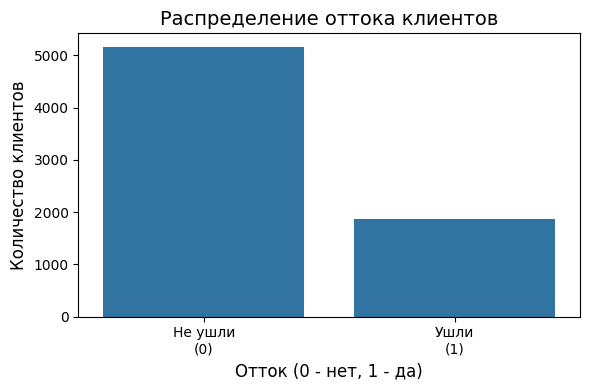

In [13]:
# Посмотрим на сбалансированность целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(x=y, legend=False)
plt.title('Распределение оттока клиентов', fontsize=14)
plt.xlabel('Отток (0 - нет, 1 - да)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.xticks([0, 1], ['Не ушли\n(0)', 'Ушли\n(1)'])
plt.tight_layout()
plt.show()

In [14]:
# Сразу разделим на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [15]:
df_train = X_train.copy()
df_train['Churn'] = y_train.values

Обрабатываем категориальные признаки:

In [16]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numeric_cols)

Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Числовые признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [17]:
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [18]:
feature_names = encoder.get_feature_names_out()
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=feature_names)
X_train_encoded_df.head(3)

,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,12.0,78.3,909.25
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,20.0,19.7,415.90
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,61.2,125.95


In [19]:
# Переведем признаки сразу на кривой русский 
feature_names = ['Пол (муж)', 'Партнер', 'Иждивенцы', 'Тел. связь', 
                'Есть ли тел.', 'Наличие неск. тел. линий',  
                 'Оптоволокно', 'Есть ли интернет', 'Пользуется ли интернетом','Онлайн-безопасность',
                 'Пользуется ли интернетом', 'Рез. копирование', 'Есть ли интернет?',
                 'Защита устройства', 'Есть ли интернет?', 'Teх. поддержка',
                 'Есть ли интернет?','Стриминг сервисы',
                 'Есть ли интернет?','Стриминговые фильмы', 
                 'Договор на год', 'Договор на 2 года', 'Безбум. выст. счетов',
                 'Автомат. оплата', 'Электронная оплата', 'Оплата по почте',
                 'Пенсионеры', 'Кол-во месяцев польз.', 'Ежемес. плата', 'Полная плата'
                 ]

In [20]:
def plot_churn_rate(df, feature, title=None):
    # Функция для построения доли ушедших клиентов
    churn_rate = df.groupby(feature)['Churn'].mean() * 100
    
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=['#e74c3c' if v > df['Churn'].mean()*100 else '#2ecc71' 
                         for v in churn_rate.values],
                  edgecolor='black', linewidth=1)
    
    for bar, v in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    if title is None:
        title = f'Churn Rate by {feature}'
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Churn Rate (%)', fontsize=12)
    ax.axhline(y=df['Churn'].mean() * 100, color='red', linestyle='--', 
               linewidth=2, label=f'Average: {df["Churn"].mean()*100:.1f}%')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(churn_rate.values) * 1.15)
    plt.tight_layout()
    plt.show()

In [21]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['font.size'] = 12

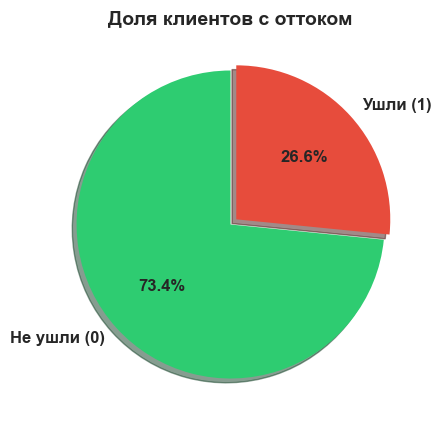

In [22]:
# Еще раз посмотрим распределение целевой переменной
churn_counts = y_train.value_counts()
labels = ['Не ушли (0)', 'Ушли (1)']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)  

plt.figure(figsize=(5, 5))
plt.pie(churn_counts, 
        labels=labels, 
        autopct='%1.1f%%',  
        colors=colors, 
        explode=explode,
        shadow=True,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Доля клиентов с оттоком', fontsize=14, fontweight='bold')
plt.show()

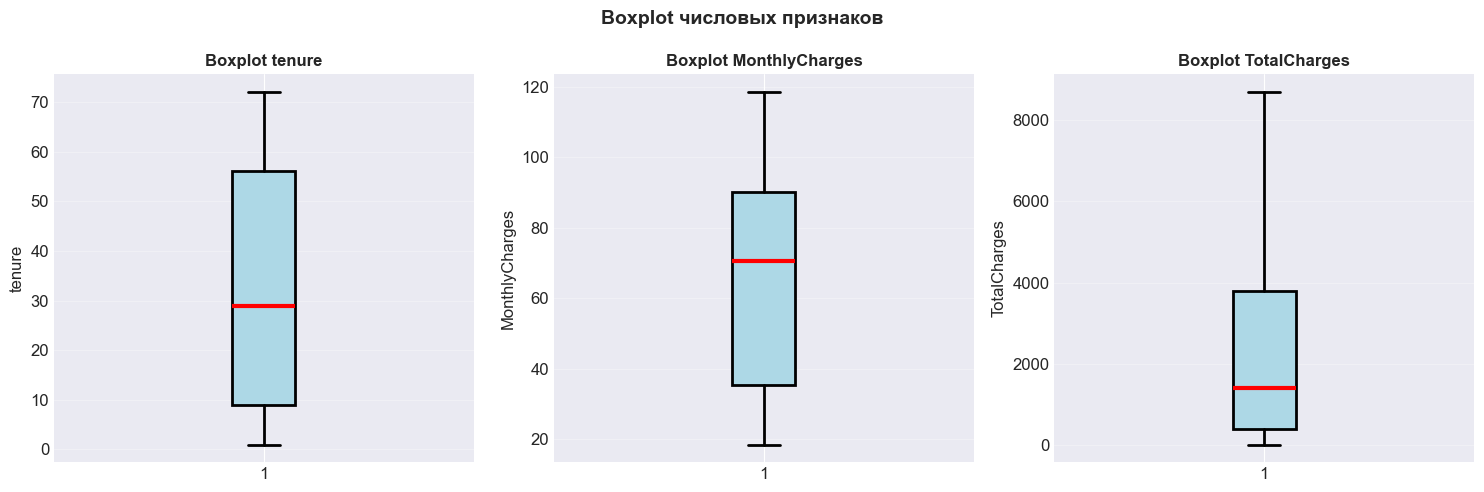

In [23]:
# Числовые переменные
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    bp = axes[i].boxplot(X_train_encoded_df[col], patch_artist=True,
                         boxprops=dict(facecolor='lightblue', linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops=dict(linewidth=2),
                         medianprops=dict(color='red', linewidth=3),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
    
    axes[i].set_title(f'Boxplot {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Boxplot числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Доля ушедших клиентов для числовых признаков
df_train.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(1)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.7,61.2,2556.3
1,18.2,74.9,1561.4


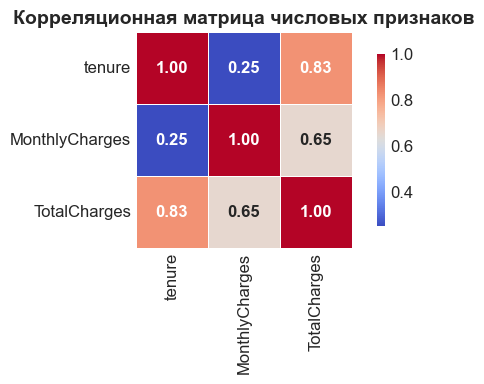

In [25]:
corr_matrix = X_train_encoded_df[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, 
            annot=True,         
            cmap='coolwarm',      
            fmt='.2f',            
            square=True,         
            linewidths=0.5,       
            cbar_kws={"shrink": 0.8}, 
            annot_kws={'size': 12, 'weight': 'bold'})  

plt.title('Корреляционная матрица числовых признаков', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
# Как тип контракта влияет на уход?
a = df_train.groupby('Contract').agg(Churn_rate = ('Churn', 'mean')).round(3).reset_index()
a

,Contract,Churn_rate
0,Month-to-month,0.429
1,One year,0.111
2,Two year,0.031


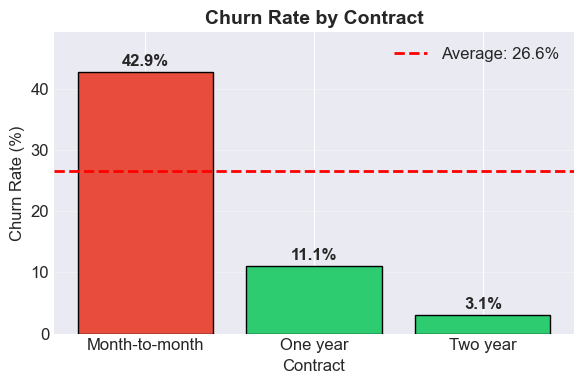

In [27]:
plot_churn_rate(df_train, 'Contract')

In [28]:
# Как доп. услуги влияют на уход клиентов?
b = df_train.groupby('InternetService').agg(Churn_rate_internetservice = ('Churn', 'mean')).round(3).reset_index()
b

,InternetService,Churn_rate_internetservice
0,DSL,0.193
1,Fiber optic,0.419
2,No,0.069


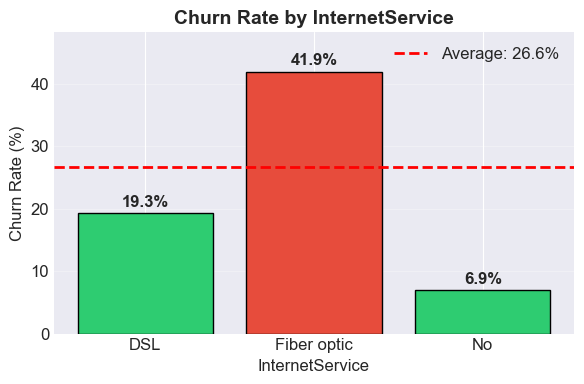

In [29]:
plot_churn_rate(df_train, 'InternetService')

In [30]:
for i in ['OnlineSecurity', 'TechSupport']:
    display(df_train.groupby(i).agg(Churn_rate = ('Churn', 'mean')).round(3).reset_index())

,OnlineSecurity,Churn_rate
0,No,0.421
1,No internet service,0.069
2,Yes,0.147


,TechSupport,Churn_rate
0,No,0.420
1,No internet service,0.069
2,Yes,0.153


In [31]:
# Связаны ли ежемес. платеж и кол-во месяцев с клиентом по категориям?
df_train['tenure_group'] = pd.cut(
    df_train['tenure'],
    bins = [0, 12, 24, 48, 72],
    labels = ['0-12', '13-24', '25-48', '49-72'],
    include_lowest = True
)
df_train.groupby('tenure_group', observed=True).agg(Churn_rate = ('Churn', 'mean')).round(3).reset_index()

df_train['MonthlyCharges_group'] = pd.cut(
    df_train['MonthlyCharges'],
    bins = [0, 40, 70, 120],
    labels = ['Low', 'Mid', 'High'],
    include_lowest = True
)
df_train.groupby('MonthlyCharges_group', observed=True).agg(Churn_rate = ('Churn', 'mean')).round(3).reset_index()

p = pd.pivot_table(
    df_train,
    index='tenure_group',
    columns='MonthlyCharges_group',
    values='Churn',
    aggfunc='mean',
    observed=True
).round(3)
p

MonthlyCharges_group,Low,Mid,High
tenure_group,,,
0-12,0.240,0.447,0.694
13-24,0.060,0.198,0.457
25-48,0.052,0.091,0.307
49-72,0.018,0.055,0.140


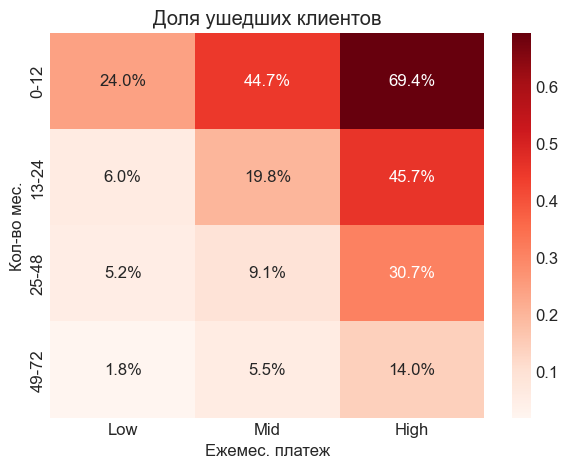

In [32]:
plt.figure(figsize=(7, 5))
sns.heatmap(p, annot=True, fmt='.1%', cmap='Reds')
plt.title('Доля ушедших клиентов')
plt.xlabel('Ежемес. платеж')
plt.ylabel('Кол-во мес.')
plt.show();


In [33]:
# Влияет ли тип оплаты?
for i in ['PaymentMethod', 'PaperlessBilling']:
    display(df_train.groupby(i).agg(Churn_rate = ('Churn', 'mean')).round(3).reset_index())

,PaymentMethod,Churn_rate
0,Bank transfer (automatic),0.159
1,Credit card (automatic),0.153
2,Electronic check,0.454
3,Mailed check,0.196


,PaperlessBilling,Churn_rate
0,No,0.162
1,Yes,0.336


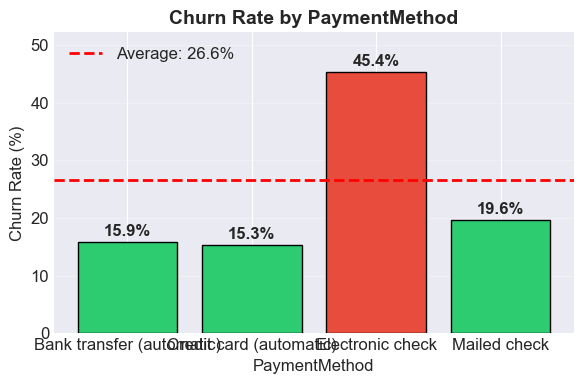

In [34]:
plot_churn_rate(df_train, 'PaymentMethod')

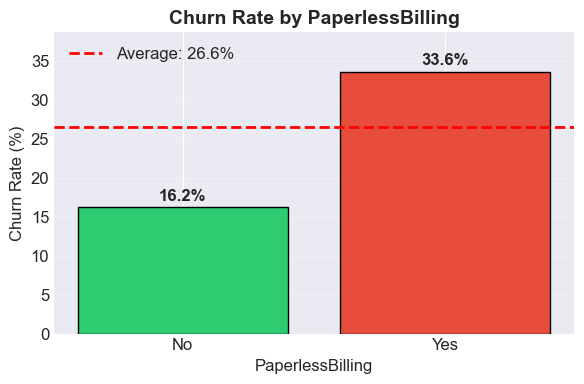

In [35]:
plot_churn_rate(df_train, 'PaperlessBilling')

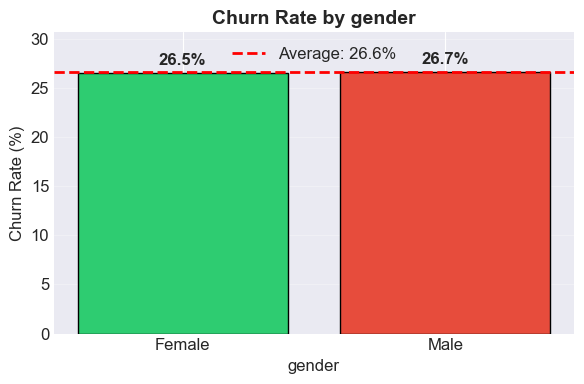

In [36]:
plot_churn_rate(df_train, 'gender')

# 6. Feature preprocessing

In [37]:
scaler = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  
    ],
    remainder='passthrough'
)


X_train_scaled = scaler.fit_transform(X_train_encoded_df)  
X_test_scaled = scaler.transform(X_test_encoded_df)

# 7. Baseline

In [38]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
model.fit(X_train_scaled, y_train)

print(f"ROC-AUC на кросс-валидации: {scores.mean():.3f} (+/- {scores.std():.3f})")
scores_acc = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
print(f"Accuracy (CV): {scores_acc.mean():.3f} (+/- {scores_acc.std():.3f})")

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

test_auc = roc_auc_score(y_test, y_pred_proba)
test_acc = (y_pred == y_test).mean()
print(f"ROC-AUC на test: {test_auc:.4f}")
print(f"Accuracy на test: {test_acc:.4f}")

baseline_results = {
    'model_name': 'Baseline (LogReg без PCA)',
    'cv_roc_auc': scores.mean(),
    'cv_roc_auc_std': scores.std(),
    'test_roc_auc': test_auc,
    'test_accuracy': test_acc
}

ROC-AUC на кросс-валидации: 0.848 (+/- 0.012)
Accuracy (CV): 0.753 (+/- 0.014)
ROC-AUC на test: 0.8378
Accuracy на test: 0.7370


Делаем PCA 

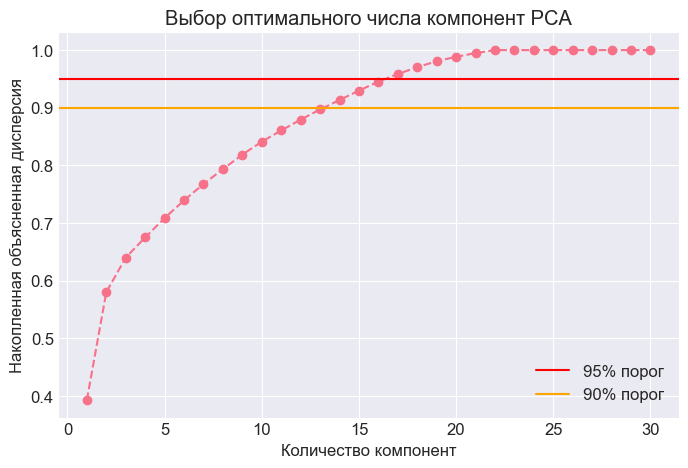

In [39]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% порог') 
plt.axhline(y=0.90, color='orange', linestyle='-', label='90% порог')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Выбор оптимального числа компонент PCA')
plt.legend()
plt.grid(True)
plt.show()

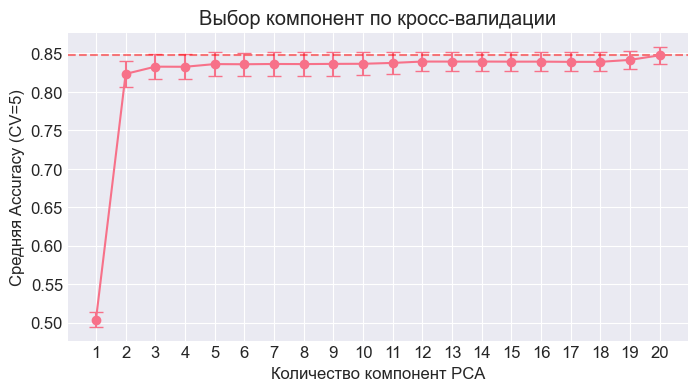

In [40]:
components_range = range(1, 21)
mean_scores = []
std_scores = []

for n in components_range:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(model, X_train_pca, y_train, cv=skf, scoring='roc_auc')
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

plt.figure(figsize=(8,4))
plt.errorbar(components_range, mean_scores, yerr=std_scores, fmt='-o', capsize=5)
plt.axhline(y=max(mean_scores), color='r', linestyle='--', alpha=0.5)
plt.xlabel('Количество компонент PCA')
plt.ylabel('Средняя Accuracy (CV=5)')
plt.title('Выбор компонент по кросс-валидации')
plt.xticks(components_range)
plt.grid(True)
plt.show()

In [41]:
best_n = 3
pca = PCA(n_components=best_n)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 8. Model comparison

In [42]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'class_weight': ['balanced'],
            'solver': ['liblinear'] 
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, None],
            'min_samples_split': [2, 5],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],         
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0] 
        }
    },
    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf'], 
            'gamma': ['scale'],
            'class_weight': ['balanced']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [5, 7, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    }
}

In [43]:
results = []

for name, config in models.items():
    print(f"Обучаем {name}...")
    
    grid_search = GridSearchCV(
        config['model'], config['params'],
        cv=skf, scoring='roc_auc', n_jobs=-1, verbose=0 
    )
    grid_search.fit(X_train_pca, y_train)
    
    y_proba = grid_search.best_estimator_.predict_proba(X_test_pca)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Модель': name,
        'Лучшие_params': grid_search.best_params_,
        'CV_ROC_AUC': grid_search.best_score_,
        'Test_ROC_AUC': test_auc,
        'Estimator': grid_search.best_estimator_,
        'y_proba': y_proba 
    })

results_df = pd.DataFrame(results).drop(columns=['Estimator', 'y_proba']).sort_values('Test_ROC_AUC', ascending=False)

Обучаем Logistic Regression...
Обучаем Random Forest...
Обучаем XGBoost...
Обучаем SVM...
Обучаем KNN...


In [44]:
print(results_df[['Модель', 'CV_ROC_AUC', 'Test_ROC_AUC']])

best_row = results[np.argmax([r['Test_ROC_AUC'] for r in results])]
best_name = best_row['Модель']
y_proba = best_row['y_proba']

print(f"Лучшая модель: {best_name}")

                Модель  CV_ROC_AUC  Test_ROC_AUC
2              XGBoost    0.842732      0.832943
1        Random Forest    0.837799      0.826902
0  Logistic Regression    0.832900      0.826398
3                  SVM    0.827912      0.810669
4                  KNN    0.816797      0.801947
Лучшая модель: XGBoost


In [45]:
print(results_df['Лучшие_params'][2])

{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


# 9. Hyperparameter tuning
Выжмем из XGBoost максимум с помощью Optuna

In [46]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_pca, y_train, cv=skf, scoring='roc_auc').mean()
    
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

best_params_optuna = study.best_params
print(f"Лучшие параметры от Optuna: {best_params_optuna}")
print(f"Лучший ROC-AUC: {study.best_value:.4f}")

Лучшие параметры от Optuna: {'n_estimators': 212, 'max_depth': 4, 'learning_rate': 0.018345565311949332, 'subsample': 0.7426058790540372, 'colsample_bytree': 0.7511761121515316, 'reg_alpha': 0.20128457774014774, 'reg_lambda': 0.09998294582602951}
Лучший ROC-AUC: 0.8433


# 10. Threshold optimization

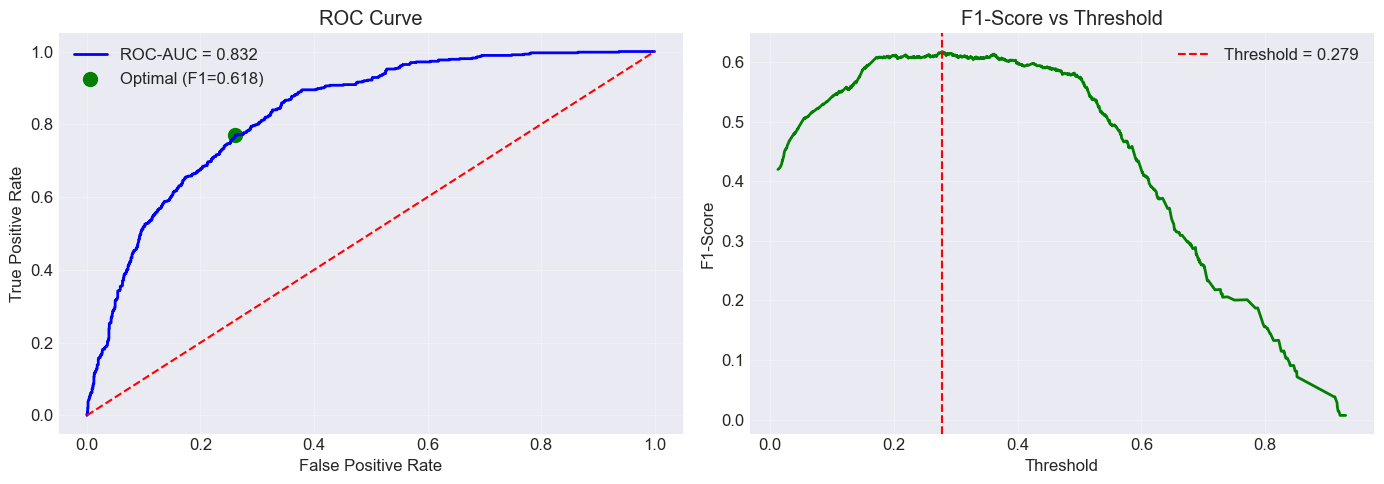

С оптимальным порогом:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1549
           1       0.52      0.77      0.62       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.80      0.75      0.76      2110



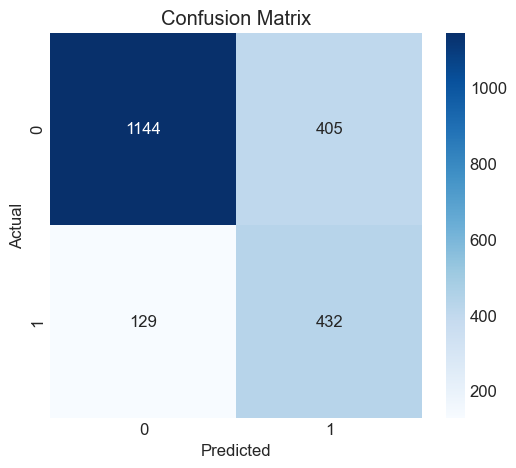

In [47]:
# Для лучших параметров найдем оптимальный порог
final_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
final_model.fit(X_train_pca, y_train)

y_proba = final_model.predict_proba(X_test_pca)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'r--')
axes[0].scatter(fpr[best_idx], tpr[best_idx], color='green', s=100, label=f'Optimal (F1={best_f1:.3f})')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_scores, 'g-', linewidth=2)
axes[1].axvline(x=best_threshold, color='red', linestyle='--', label=f'Threshold = {best_threshold:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Threshold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


y_pred = (y_proba >= best_threshold).astype(int)

print("С оптимальным порогом:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

# 11. Model interpretation with SHAP

In [48]:
final_model_for_interpretation = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
final_model_for_interpretation.fit(X_train_scaled, y_train)

explainer = shap.TreeExplainer(final_model_for_interpretation)
shap_values = explainer.shap_values(X_test_scaled)

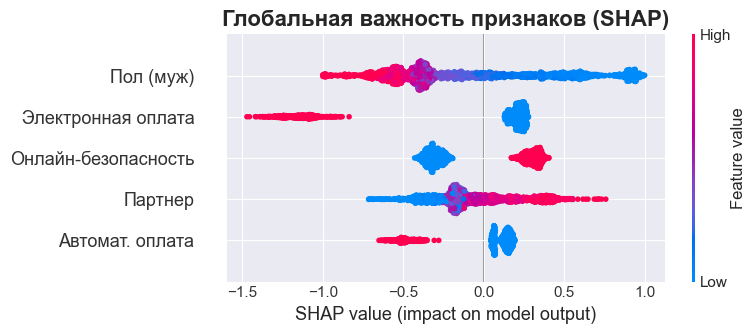

In [49]:
explainer = shap.TreeExplainer(final_model_for_interpretation)
X_sample = X_test_scaled
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=5, feature_names=feature_names)
plt.title("Глобальная важность признаков (SHAP)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

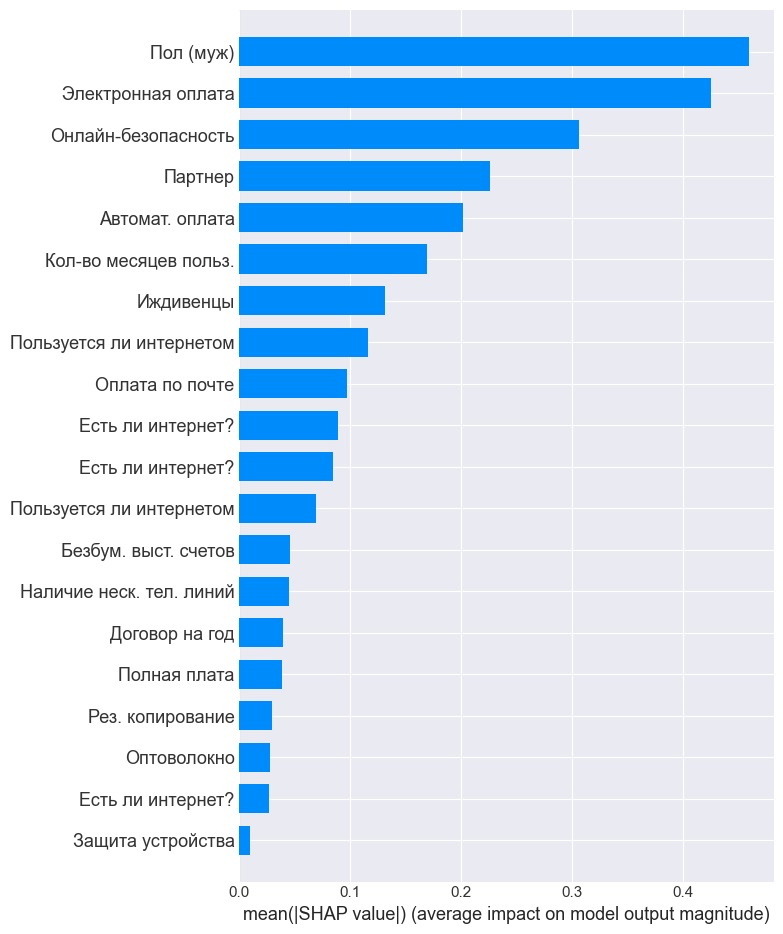

In [50]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type='bar',
    feature_names = feature_names
)

Оценка финансового риска:

In [51]:
risk_df = X_test_encoded_df.copy()
risk_df['Actual'] = y_test
risk_df['ChurnProbability'] = y_proba

risk_df['RevenueRisk'] = (
    risk_df['MonthlyCharges']
    * risk_df['ChurnProbability']
)
total_risk = risk_df['RevenueRisk'].sum()
print(f"Предполагаемый доход, подверженный риску: ${total_risk:,.2f}")

Предполагаемый доход, подверженный риску: $42,180.17


# 12. Customer risk segmentation

In [52]:
risk_df['RiskSegment'] = pd.cut(
    risk_df['ChurnProbability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Низкий риск', 'Средний риск', 'Высокий риск'],
    include_lowest=True
)

print(risk_df[['ChurnProbability', 'RiskSegment']].head())

   ChurnProbability  RiskSegment
0          0.127360  Низкий риск
1          0.247198  Низкий риск
2          0.080542  Низкий риск
3          0.045333  Низкий риск
4          0.133411  Низкий риск


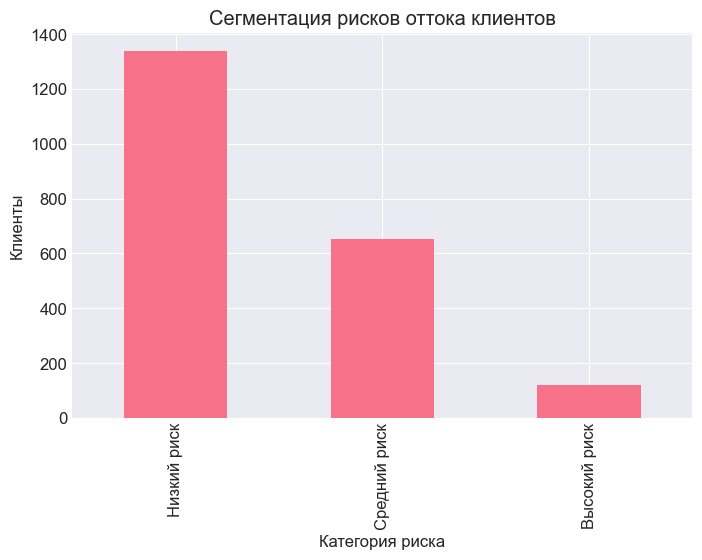

In [53]:
segment_counts = risk_df['RiskSegment'].value_counts()

plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title("Сегментация рисков оттока клиентов")
plt.ylabel("Клиенты")
plt.xlabel("Категория риска")

plt.show()

In [54]:
top_risk = risk_df.sort_values(
    'RevenueRisk',
    ascending=False
)

top_risk.head(10)
top_risk[['RevenueRisk', 'RiskSegment']].head(10)

,RevenueRisk,RiskSegment
156,92.236491,Высокий риск
1850,91.544689,Высокий риск
188,89.807945,Высокий риск
1929,88.413412,Высокий риск
965,88.030284,Высокий риск
1615,87.405049,Высокий риск
1012,87.035833,Высокий риск
145,86.856717,Высокий риск
972,86.727476,Высокий риск
750,86.369301,Высокий риск


# 13. Conclusions

*Ключевые бизнес-выводы:*

1. Контракт — рычаг №1. П
Перевод клиента с month-to-month на годовой снижает вероятность ухода кратно.

2. Первые 6–12 месяцев — критическое окно.
Onboarding-программа окупается.

3. Fiber optic требует продуктового аудита.
Возможно, проблема в цене/качестве, а не в клиентах.

4. Отсутствие TechSupport / OnlineSecurity = отсутствие switching cost.
Бандлинг — дешёвый способ удержания.

5. Порог 0.4, а не 0.5.
В retention-задачах лучше «перестраховаться», чем пропустить уходящего